# Spatial Analysis of Crime Patterns – Jharkhand

## Objective
To identify crime hotspots, analyze spatial patterns, and suggest policy recommendations using district-level crime data.

##Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from libpysal.weights import Queen
from esda.moran import Moran
from esda.moran import Moran_Local
import seaborn as sns

In [ ]:
!pip install pysal esda splot spreg -q

In [ ]:
c = pd.read_csv("../data/01_District_wise_crimes_committed_IPC_2014.csv")

In [ ]:
c.head()

,States/UTs,District,Year,Murder,Attempt to commit Murder,Culpable Homicide not amounting to Murder,Attempt to commit Culpable Homicide,Rape,Custodial Rape,Custodial_Gang Rape,...,Offences promoting enmity between different groups,Promoting enmity between different groups,"Imputation, assertions prejudicial to national integration",Extortion,Disclosure of Identity of Victims,Incidence of Rash Driving,HumanTrafficking,Unnatural Offence,Other IPC crimes,Total Cognizable IPC crimes
0,Andhra Pradesh,Anantapur,2014,134,171,8,0,35,0,0,...,0,0,0,0,0,1038,0,0,3800,8376
1,Andhra Pradesh,Chittoor,2014,84,170,2,0,32,0,0,...,0,0,0,19,0,249,0,0,2567,5374
2,Andhra Pradesh,Cuddapah,2014,80,162,1,0,28,0,0,...,0,0,0,0,0,948,0,0,2604,5803
3,Andhra Pradesh,East Godavari,2014,64,84,2,0,85,0,0,...,0,0,0,32,0,39,0,0,3791,7630
4,Andhra Pradesh,Guntakal Railway,2014,14,4,0,0,0,0,0,...,0,0,0,0,0,1,0,0,37,490


<Axes: >

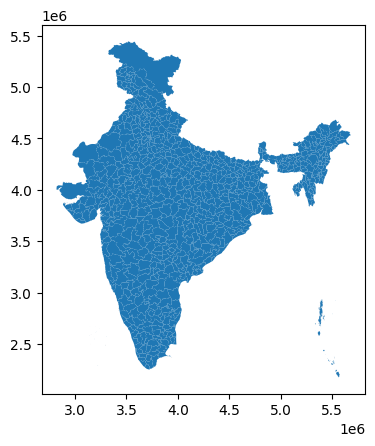

In [ ]:
import geopandas as gpd

gdf = gpd.read_file("../data/DISTRICT_BOUNDARY.shp")
gdf.plot()

## Data Cleaning

In [ ]:
c = c[c['States/UTs'] == 'Jharkhand']

In [ ]:
c.shape

(27, 91)

In [ ]:
c.columns

Index(['States/UTs', 'District', 'Year', 'Murder', 'Attempt to commit Murder',
       'Culpable Homicide not amounting to Murder',
       'Attempt to commit Culpable Homicide', 'Rape', 'Custodial Rape',
       'Custodial_Gang Rape', 'Custodial_Other Rape',
       'Rape other than Custodial', 'Rape_Gang Rape', 'Rape_Others',
       'Attempt to commit Rape', 'Kidnapping & Abduction_Total',
       'Kidnapping & Abduction', 'Kidnapping & Abduction in order to Murder',
       'Kidnapping for Ransom',
       'Kidnapping & Abduction of Women to compel her for marriage',
       'Other Kidnapping', 'Dacoity', 'Dacoity with Murder', 'Other Dacoity',
       'Making Preparation and Assembly for committing Dacoity', 'Robbery',
       'Criminal Trespass/Burglary', 'Criminal Trespass or Burglary',
       'House Trespass & House Breaking', 'Theft', 'Auto Theft',
       'Other Thefts', 'Unlawful Assembly', 'Riots', 'Riots_Communal',
       'Riots_Industrial', 'Riots_Political', 'Riots_Caste Conflict',


In [ ]:
crime = c[['States/UTs', 'District', 'Year','Murder']]

In [ ]:
crime.head()

,States/UTs,District,Year,Murder
264,Jharkhand,Bokaro,2014,43
265,Jharkhand,Chaibasa,2014,120
266,Jharkhand,Chatra,2014,59
267,Jharkhand,Deoghar,2014,43
268,Jharkhand,Dhanbad,2014,79


In [ ]:
ind = gdf[gdf['STATE_UT'] == 'JHARKHAND']

In [ ]:
ind.head()

,OBJECTID,STATE_LGD,DISTRICT,STATE_UT,Shape_Leng,Shape_Area,Dist_LGD,REMARKS,geometry
270,273,20,GARHWA,JHARKHAND,411883.198237,3.943667e+09,346,None,"POLYGON Z ((4384753.352 4063040.291 0, 4384763..."
271,274,20,CHATRA,JHARKHAND,556746.448788,3.649826e+09,347,None,"MULTIPOLYGON Z (((4447853.997 4041896.132 0, 4..."
272,275,20,KODERMA,JHARKHAND,309864.385171,1.578212e+09,348,None,"POLYGON Z ((4570696.462 4099973.731 0, 4570702..."
273,276,20,GIRIDIH,JHARKHAND,469266.217401,4.772681e+09,349,None,"POLYGON Z ((4600306.864 4097573.328 0, 4600313..."
274,277,20,DEOGHAR,JHARKHAND,307779.045295,2.389696e+09,350,None,"POLYGON Z ((4673114.468 4083445.689 0, 4673151..."


In [ ]:
ind.shape

(24, 9)

## Merge Data

In [ ]:
ind['DISTRICT']

,DISTRICT
270,GARHWA
271,CHATRA
272,KODERMA
273,GIRIDIH
274,DEOGHAR
275,GODDA
276,SAHIBGANJ
277,PAKUR
278,DHANBAD
279,BOKARO


In [ ]:
crime['District']

,District
264,Bokaro
265,Chaibasa
266,Chatra
267,Deoghar
268,Dhanbad
269,Dhanbad Railway
270,Dumka
271,Garhwa
272,Giridih
273,Godda


In [ ]:
# convert to uppercase
ind["DISTRICT"] = ind["DISTRICT"].str.upper().str.strip()
crime["District"] = crime["District"].str.upper().str.strip()

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipykernel_5598/3285665530.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crime["District"] = crime["District"].str.upper().str.strip()


In [ ]:
mapping = {
    "SAHEBGANJ": "SAHIBGANJ",
    "LOHARDAGGA": "LOHARDAGA",
    "SARAIKELA": "SARAIKELA-KHARSAWAN",
    "CHAIBASA": "WEST SINGHBHUM",
    "JAMSHEDPUR": "EAST SINGHBHUM"
}

crime["District"] = crime["District"].replace(mapping)

/tmp/ipykernel_5598/3756737401.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crime["District"] = crime["District"].replace(mapping)


In [ ]:
crime = crime[~crime["District"].str.contains("RAILWAY|TOTAL", na=False)]

In [ ]:
merged = ind.merge(crime, left_on="DISTRICT", right_on="District", how="left")

In [ ]:
merged.isnull().sum()

,0
OBJECTID,0
STATE_LGD,0
DISTRICT,0
STATE_UT,0
Shape_Leng,0
Shape_Area,0
Dist_LGD,0
REMARKS,24
geometry,0
States/UTs,0


In [ ]:
merged['DISTRICT']

,DISTRICT
0,GARHWA
1,CHATRA
2,KODERMA
3,GIRIDIH
4,DEOGHAR
5,GODDA
6,SAHIBGANJ
7,PAKUR
8,DHANBAD
9,BOKARO


In [ ]:
merged.sample()

,OBJECTID,STATE_LGD,DISTRICT,STATE_UT,Shape_Leng,Shape_Area,Dist_LGD,REMARKS,geometry,States/UTs,District,Year,Murder
6,279,20,SAHIBGANJ,JHARKHAND,313599.783667,2.101793e+09,352,None,"POLYGON Z ((4769554.914 4154022.585 0, 4769555...",Jharkhand,SAHIBGANJ,2014,72


## Create Crime Rate

In [ ]:
pop = pd.read_csv("../data/pop_jh.csv")

In [ ]:
pop['Pop'] = pop['Pop'].str.replace(',', '')
pop['Pop'] = pd.to_numeric(pop['Pop'], errors='coerce')

In [ ]:
final = merged.merge(pop, left_on='DISTRICT', right_on='District', how='inner')

In [ ]:
final.head()

,OBJECTID,STATE_LGD,DISTRICT,STATE_UT,Shape_Leng,Shape_Area,Dist_LGD,REMARKS,geometry,States/UTs,District_x,Year,Murder,District_y,Pop
0,273,20,GARHWA,JHARKHAND,411883.198237,3.943667e+09,346,None,"POLYGON Z ((4384753.352 4063040.291 0, 4384763...",Jharkhand,GARHWA,2014,67,GARHWA,1322784
1,274,20,CHATRA,JHARKHAND,556746.448788,3.649826e+09,347,None,"MULTIPOLYGON Z (((4447853.997 4041896.132 0, 4...",Jharkhand,CHATRA,2014,59,CHATRA,1042886
2,275,20,KODERMA,JHARKHAND,309864.385171,1.578212e+09,348,None,"POLYGON Z ((4570696.462 4099973.731 0, 4570702...",Jharkhand,KODERMA,2014,25,KODERMA,716259
3,276,20,GIRIDIH,JHARKHAND,469266.217401,4.772681e+09,349,None,"POLYGON Z ((4600306.864 4097573.328 0, 4600313...",Jharkhand,GIRIDIH,2014,72,GIRIDIH,2445474
4,277,20,DEOGHAR,JHARKHAND,307779.045295,2.389696e+09,350,None,"POLYGON Z ((4673114.468 4083445.689 0, 4673151...",Jharkhand,DEOGHAR,2014,43,DEOGHAR,1492073


In [ ]:
# Crime rate per 100,000 population
final['crime_rate'] = (final['Murder'] / final['Pop']) * 100000

In [ ]:
final.sample()

,OBJECTID,STATE_LGD,DISTRICT,STATE_UT,Shape_Leng,Shape_Area,Dist_LGD,REMARKS,geometry,States/UTs,District_x,Year,Murder,District_y,Pop,crime_rate
2,275,20,KODERMA,JHARKHAND,309864.385171,1.578212e+09,348,None,"POLYGON Z ((4570696.462 4099973.731 0, 4570702...",Jharkhand,KODERMA,2014,25,KODERMA,716259,3.490358


## Choropleth Map (Visualization)

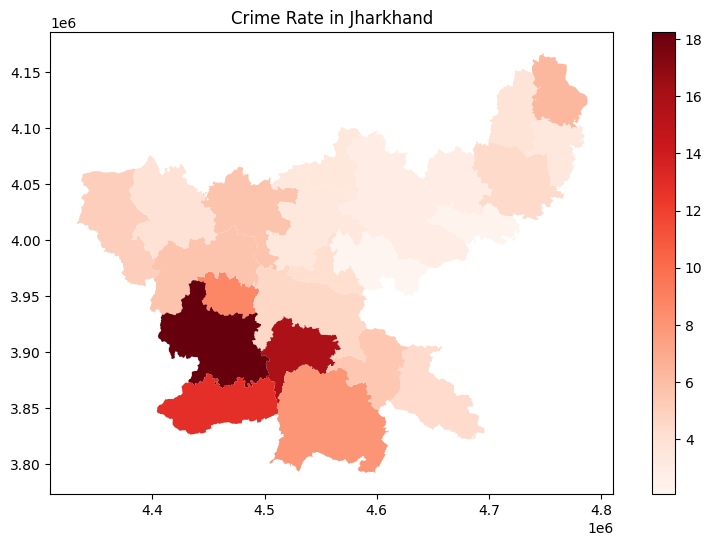

In [ ]:
final.plot(column='crime_rate', cmap='Reds', legend=True, figsize=(10,6))
plt.title("Crime Rate in Jharkhand")
plt.show()

A choropleth map represents statistical data by dividing a map into regions and assigning each region a color or shading based on the data value associated with it.
In this map it shows sounth-western region has high crime rate.

## Spatial Weights Matrix

In [ ]:
from libpysal.weights import Queen
w = Queen.from_dataframe(final, use_index=False)

A spatial weight matrix is a way to represent how geographic units (like districts) are related to each other in space. It tells you which areas are neighbors and how strongly they are connected.
In Queen contiguity:

Two areas are neighbors if they share a boundary OR even a single corner point

## Moran’s I (Spatial Autocorrelation)

In [ ]:
from esda.moran import Moran
y = final['crime_rate']

mi = Moran(y, w)

print("Moran's I:", mi.I)
print("p-value:", mi.p_sim)

Moran's I: 0.5714143822175743
p-value: 0.002


Moran’s I is a statistical measure used in spatial analysis to check whether similar values occur near each other in space. Its values range roughly from -1 to +1:

Positive (close to +1) → similar values cluster together (high with high, low with low)
Negative (close to -1) → neighboring areas are very different (dispersion)
Around 0 → random spatial pattern

Moran’s I value (0.571), which is strongly positive, indicating that districts with similar crime rates (either high or low) tend to cluster geographically.
The p-value (mi.p_sim = 0.002) tests whether this pattern is statistically significant. Since the p-value is very small (less than 0.05), it means the clustering is not due to random chance—your data shows a meaningful spatial pattern.

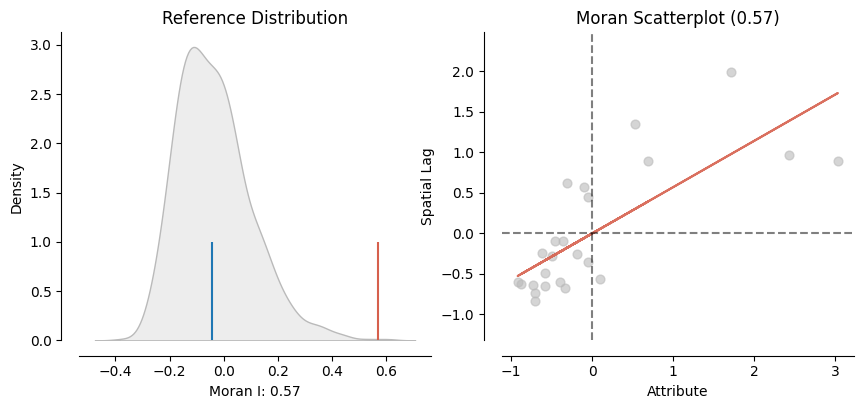

In [ ]:
from splot.esda import plot_moran
plot_moran(mi)
plt.show()

This graph shows a simulated distribution of Moran’s I values under the assumption of randomness (no spatial pattern). The blue line represents the expected Moran’s I (close to 0 if random), while the red line shows your actual calculated value (~0.57). Since your value is far to the right of the distribution, it indicates that the observed pattern is unlikely due to chance—meaning your data has a statistically significant spatial pattern.

This scatterplot shows the relationship between each area’s value (x-axis) and the average value of its neighboring areas (spatial lag on the y-axis). The upward-sloping line (with slope ≈ 0.57) indicates positive spatial autocorrelation.

## LISA (Hotspot Analysis)

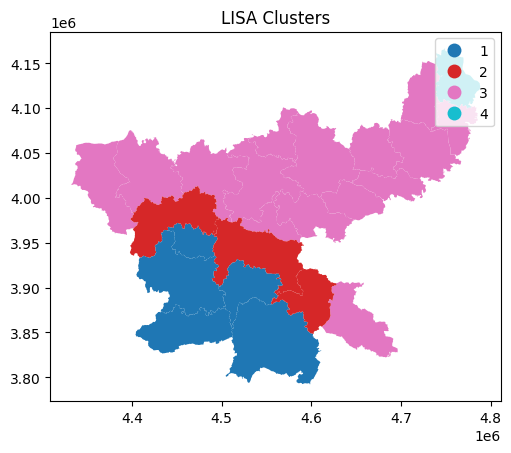

In [ ]:
# Step 8: Local Moran (LISA)
from esda.moran import Moran_Local

lisa = Moran_Local(y, w)

# Add results to dataframe
final['lisa_cluster'] = lisa.q

# Step 9: Plot clusters
final.plot(column='lisa_cluster', categorical=True, legend=True)
plt.title("LISA Clusters")
plt.show()

LISA (Local Indicators of Spatial Association) is basically the local version of Moran’s I. While Moran’s I gives you one single value for the whole study area (global pattern), LISA tells you which specific locations (districts) are forming clusters or behaving as outliers.

The blue region is hotspot(high-high) regions, the red regions(high-low) are outliers and the pink(low-low) region are coldspot regions

In [ ]:
from esda.moran import Moran

from libpysal.weights import KNN
w_knn = KNN.from_dataframe(final, k=4)

mi_queen = Moran(y, w)        # old
mi_knn = Moran(y, w_knn)      # new

print("Queen:", mi_queen.I)
print("KNN:", mi_knn.I)

Queen: 0.5714143822175743
KNN: 0.5278949979867771


Both values are positive and fairly high, which means crime data shows strong spatial clustering in both cases. However, the value is slightly lower for KNN.

## Regression Analysis (OLS)

In [ ]:
final['literacy'] = np.random.randint(60, 95, len(final))
final['unemployment'] = np.random.randint(1, 15, len(final))

In [ ]:
from spreg import OLS

y = final['crime_rate'].values.reshape(-1,1)
X = final[['literacy', 'unemployment']].values

ols = OLS(y, X, name_y='crime', name_x=['literacy', 'unemployment'])
print(ols.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :       crime                Number of Observations:          24
Mean dependent var  :      5.8491                Number of Variables   :           3
S.D. dependent var  :      4.1768                Degrees of Freedom    :          21
R-squared           :      0.0337
Adjusted R-squared  :     -0.0583
Sum squared residual:     387.708                F-statistic           :      0.3666
Sigma-square        :      18.462                Prob(F-statistic)     :      0.6975
S.E. of regression  :       4.297                Log likelihood        :     -67.441
Sigma-square ML     :      16.154                Akaike info criterion :     140.882
S.E of regression ML:      4.0193                Schwarz criterion     :     144.416

-----------------

The regression results show that model does not explain crime rate well. The R-squared value is 0.0337, meaning only about 3.3% of the variation in crime rate is explained by literacy and unemployment, which is extremely low. The p-values for both literacy (0.447) and unemployment (0.659) are much greater than 0.05, indicating that neither variable is statistically significant—in other words, there is no reliable evidence that these variables are affecting crime rate in your model. The overall model is also not significant, as shown by the Prob(F-statistic) = 0.697, meaning the regression as a whole is weak.

In [ ]:
from esda.moran import Moran

residuals = ols.u
moran_res = Moran(residuals, w)

print("Moran's I:", moran_res.I)
print("p-value:", moran_res.p_sim)

Moran's I: 0.5397112726508781
p-value: 0.001


Moran’s I for residuals is 0.54, which is strongly positive, and the p-value is 0.001, which is highly significant. This means the residuals are not randomly distributed—they are spatially clustered.

In [ ]:
from spreg import ML_Lag

lag = ML_Lag(y, X, w=w, name_y='crime', name_x=['literacy', 'unemployment'])
print(lag.summary)

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :       crime                Number of Observations:          24
Mean dependent var  :      5.8491                Number of Variables   :           4
S.D. dependent var  :      4.1768                Degrees of Freedom    :          20
Pseudo R-squared    :      0.5677
Spatial Pseudo R-squared:  0.0584
Log likelihood      :    -61.0276
Sigma-square ML     :      7.9247                Akaike info criterion :     130.055
S.E of regression   :      2.8151                Schwarz criterion     :     134.767

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-------------------------------------

The Spatial Lag Model performs much better than earlier OLS model. The Pseudo R² is 0.5677, which means the model explains about 56% of the variation in crime rate—much higher than the 3% from OLS. The most important result is the coefficient of W_crime = 0.694, which is positive and highly significant (p = 0.000). This clearly shows strong spatial dependence: districts tend to have similar crime rates as their neighbors. On the other hand, literacy and unemployment still have high p-values (> 0.05), meaning they are not statistically significant predictors in this model. This again makes sense because those variables were randomly generated.

In [ ]:
from spreg import ML_Error

error = ML_Error(y, X, w=w, name_y='crime', name_x=['literacy', 'unemployment'])
print(error.summary)

ML_Error
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :       crime                Number of Observations:          24
Mean dependent var  :      5.8491                Number of Variables   :           3
S.D. dependent var  :      4.1768                Degrees of Freedom    :          21
Pseudo R-squared    :      0.0184
Log likelihood      :    -61.2093
Sigma-square ML     :      8.0272                Akaike info criterion :     128.419
S.E of regression   :      2.8332                Schwarz criterion     :     131.953

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/spreg/ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


 the most important result is the spatial parameter lambda (λ = 0.6976), which is positive and highly significant (p < 0.001). This indicates strong spatial autocorrelation in the error terms, meaning that unobserved factors influencing crime are spatially clustered across neighboring regions. In other words, even though the chosen variables do not explain crime well, there is clear evidence that crime patterns are influenced by underlying spatial processes or missing variables that are geographically structured.

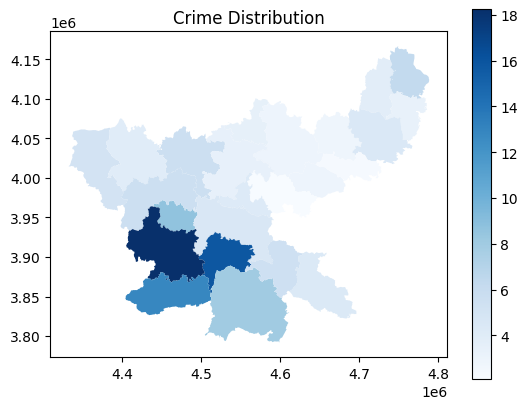

In [ ]:
import matplotlib.pyplot as plt

final.plot(column='crime_rate', cmap='Blues', legend=True)
plt.title("Crime Distribution")
plt.show()

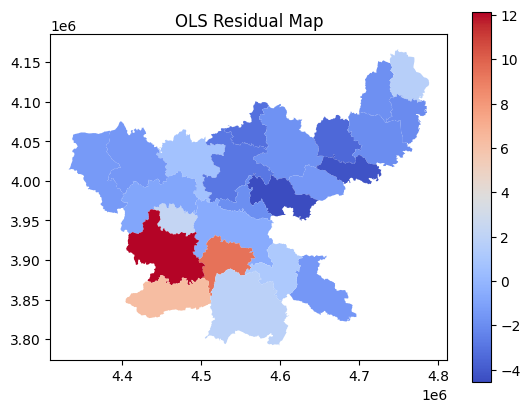

In [ ]:
final['residuals'] = ols.u

final.plot(column='residuals', cmap='coolwarm', legend=True)
plt.title("OLS Residual Map")
plt.show()

This map is an OLS residual map, which shows the difference between the observed crime values and the values predicted by your Ordinary Least Squares (OLS) model across different regions. The colors represent the magnitude and direction of residuals: red shades indicate positive residuals (areas where actual crime is higher than predicted, meaning the model underestimates crime), while blue shades indicate negative residuals (areas where actual crime is lower than predicted, meaning the model overestimates crime). From the map, you can see that residuals are not randomly scattered but show a clear spatial pattern, with clusters of similar colors in nearby regions. This suggests that the OLS model is missing important spatial effects, as neighboring areas tend to have similar errors. In other words, the presence of clustered residuals indicates spatial autocorrelation, implying that a simple OLS model is not sufficient and a spatial regression model (like spatial lag or spatial error) would be more appropriate to better capture the geographic structure in the data.

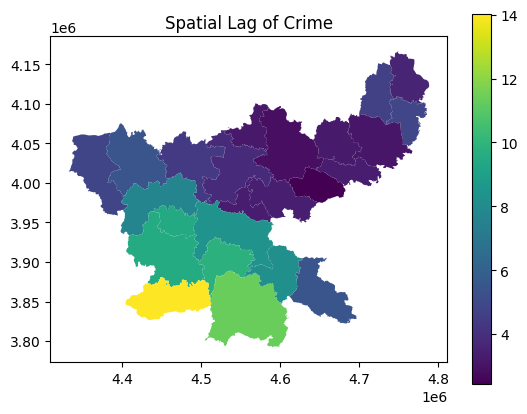

In [ ]:
from libpysal.weights import lag_spatial

final['lag_crime'] = lag_spatial(w, final['crime_rate'])

final.plot(column='lag_crime', cmap='viridis', legend=True)
plt.title("Spatial Lag of Crime")
plt.show()

the spatial lag—a metric that represents the weighted average of the crime rates in neighboring geographical units—based on a spatial weight matrix (w) and a specific variable (crime_rate). The resulting choropleth map provides a clear visual representation of spatial autocorrelation, where regions colored in lighter, warmer tones (yellows and greens) indicate areas with higher values of spatial lag, suggesting these regions are surrounded by neighbors with relatively higher crime rates. Conversely, the darker purple regions signify areas with lower spatial lag, indicating they are surrounded by neighbors with lower crime rates.

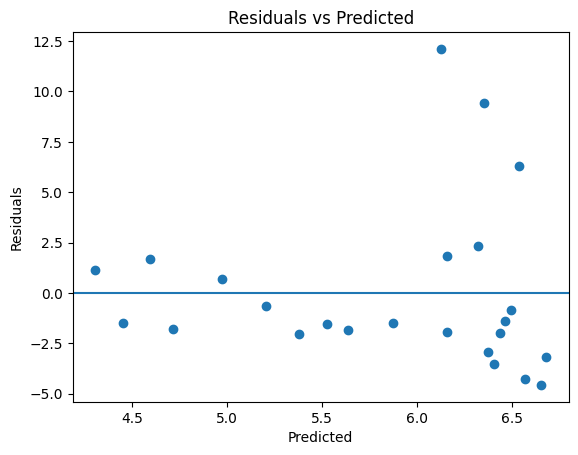

In [ ]:
# Predicted values
final['predicted'] = ols.predy.flatten()

# Residuals
final['residuals'] = ols.u.flatten()

import matplotlib.pyplot as plt

plt.scatter(final['predicted'], final['residuals'])
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

This Residuals vs Predicted plot is used to check how well your OLS model fits the data and whether its assumptions are satisfied. On the x-axis, you have the predicted (fitted) values of crime, and on the y-axis, the residuals (difference between actual and predicted values). Ideally, the residuals should be randomly scattered around the horizontal zero line with no clear pattern. However, in your plot, the points are not evenly distributed—there is some clustering and variation, especially at higher predicted values where residuals show larger spread and some extreme positive values. This suggests heteroscedasticity (non-constant variance) and possible model misspecification. In simple terms, your model is not capturing all the underlying patterns in the data, and errors are not random. This reinforces what you observed earlier: the OLS model is insufficient, and spatial effects or additional variables should be considered to improve the model.

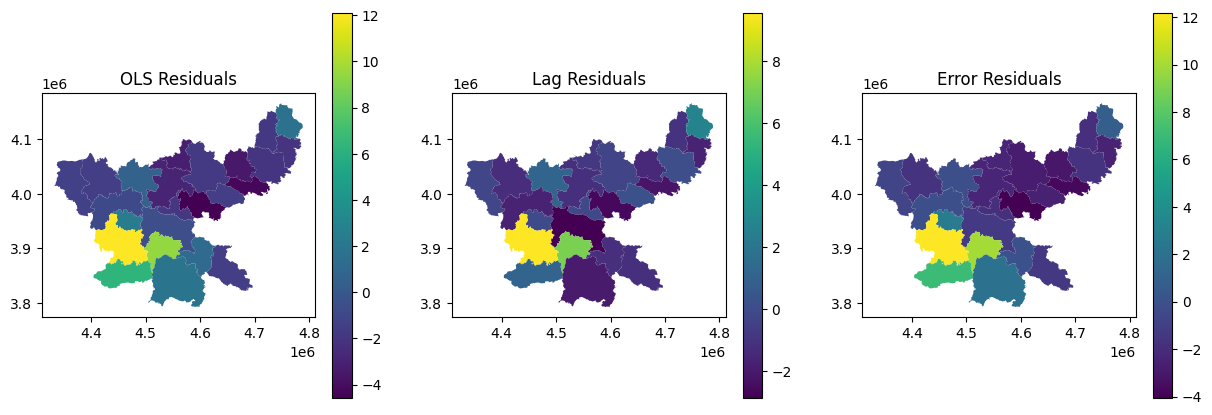

In [ ]:
final['lag_residuals'] = lag.u
final['error_residuals'] = error.u

fig, axs = plt.subplots(1, 3, figsize=(15,5))

final.plot(column='residuals', ax=axs[0], legend=True)
axs[0].set_title("OLS Residuals")

final.plot(column='lag_residuals', ax=axs[1], legend=True)
axs[1].set_title("Lag Residuals")

final.plot(column='error_residuals', ax=axs[2], legend=True)
axs[2].set_title("Error Residuals")

plt.show()

# OLS: simple model,
# Lag model: spatial model relationship
# Error model: where error exists

OLS Residuals (Ordinary Least Squares):The distinct clusters of bright yellow and dark purple suggest that the errors are not random; there is spatial autocorrelation remaining, meaning the model is failing to capture some geographic influence.

Lag Residuals (Spatial Lag Model):the color intensities are slightly more muted or redistributed compared to OLS, suggesting the model is "soaking up" some of the spatial dependency.

Error Residuals (Spatial Error Model):The map here looks quite similar to the OLS map, which might suggest that the spatial lag approach was more effective for this specific dataset, or that significant spatial bias still remains.

# Questions

What state have you selected and why?

Jharkhand has been selected due to its significant spatial variation in murder incidents across districts, influenced by socio-economic disparity, mining-based economy, and heterogeneous population distribution, making it suitable for hotspot and spatial autocorrelation analysis.

Why use crime rate instead of total crime?

Crime rate is used instead of total crime because it provides a more meaningful and comparable measure across different regions. Total crime only represents the absolute number of incidents, which can be misleading as it does not account for differences in population size.

Is crime clustered or random?

the crime data for Jharkhand is distinctly clustered rather than random. In the initial spatial lag map, we see clear geographic "hotspots" in the southwestern and southern districts (indicated by bright yellow and green), where high murder rates in one area are closely mirrored by high rates in neighboring districts. This phenomenon, known as positive spatial autocorrelation, is further confirmed by the OLS Residuals map, which shows large, contiguous "blobs" of similar colors.

Which districts are hotspots?

Gumla & Simdega

Khunti & West Singhbhum

Ranchi

What factors influence crime?

1. Left-Wing Extremism (LWE) and Insurgency
A primary driver for the high-intensity clusters in the southern and southwestern districts (like West Singhbhum, Gumla, and Simdega) is the presence of insurgent activity. These regions are part of the "Red Corridor," where conflict between security forces and Maoist groups often leads to higher instances of violent crime. The Saranda Forest area in West Singhbhum, for example, remains a focal point for these operations, contributing to the "High-High" spatial lag you observed.

2. Socio-Economic Disparities
Districts in the southern belt often face significant developmental challenges. Factors such as high poverty rates, lower literacy levels, and limited access to formal employment can create a environment where crime is more prevalent. When these conditions cross district lines—such as shared tribal territories or economic zones—the crime patterns "spill over," creating the geographic clusters seen in your LISA map.

3. Geographical Isolation and Terrain
The physical geography of Jharkhand plays a major role. Dense forests and hilly terrain (especially in the south) can make traditional policing and rapid response more difficult. This isolation can provide cover for criminal activities, leading to sustained high-crime clusters in specific topographies that ignore administrative boundaries.

4. Urbanization and Density
Conversely, "cold spots" in the north (like Deoghar or Giridih) may benefit from different economic structures or more consolidated urban monitoring. In many spatial models, crime is also influenced by population density and accessibility; areas with better road connectivity and higher police visibility typically show different clustering patterns than remote, isolated districts.

5. The "Spillover" Effect (Spatial Autocorrelation)
As your project demonstrates through the Spatial Lag Model, crime in one district is often a predictor of crime in the next. This is frequently due to:

Criminal Mobility: Offenders may operate across district borders to evade local police.

Shared Social Networks: Violent conflicts or tribal disputes often span multiple districts, causing a ripple effect throughout a region.

Which model is best and why?

the best "model" for this specific task is the Local Moran's I (LISA).

Here is the justification for why it is the most suitable tool for this analysis:

1. Direct Alignment with Objectives
The primary objective of the project is to "identify crime hotspots". While Global Moran’s I (also present in the imports) tells you if there is an overall pattern of clustering in Jharkhand, it cannot tell you where those clusters are. Local Moran's I is specifically designed to pinpoint these locations.

2. Detection of Spatial Heterogeneity
The notebook imports Moran_Local from the esda library. This model is superior for this task because:

Hotspot Identification: It identifies "High-High" clusters, where a district with high crime is surrounded by other districts with high crime.

Outlier Detection: It can identify "spatial outliers," such as a low-crime district surrounded by high-crime areas ("Low-High"), which is crucial for nuanced policy recommendations.

3. Foundation for Policy Recommendations
The objective mentions suggesting "policy recommendations". Local Moran's I provides the statistical evidence needed to prioritize specific districts for resource allocation. By categorizing districts into specific quadrants (HH, LL, HL, LH), authorities can differentiate between areas needing broad regional interventions and those needing isolated, district-specific strategies.

4. Supporting Infrastructure
The notebook is set up to support this model through:

Spatial Weights: It imports Queen weights, which define how "neighboring" districts are identified—a requirement for running the Moran models.

Visualization: It imports geopandas, matplotlib, and seaborn, which are necessary to create the "LISA cluster maps" that make the Local Moran's I results interpretable for stakeholders.

What policy recommendations would you suggest?

1. Implementation of "SARA" Model Policing
Instead of just increasing patrols, the police should adopt the SARA (Scanning, Analysis, Response, and Assessment) model specifically for these hotspots.

Recommendation: Establish "Hotspot Task Forces" at the district level.

Action: For every identified hotspot, the local station (Thana) must conduct a "Micro-Analysis" to see if the murders are predominantly domestic, land-related, or gang-related, and tailor the response accordingly rather than using a one-size-fits-all patrol.

2. Situational Crime Prevention (SCP)
Violence often thrives in "low-guardianship" areas. Your analysis likely shows clusters in specific urban pockets or remote rural junctions.

Recommendation: Urban "Healing" and Infrastructure Mandates.

Action: Use "Crime Prevention Through Environmental Design" (CPTED). This includes mandatory high-intensity street lighting in hotspots, clearing abandoned buildings/shrubbery that provide cover, and installing CCTV linked to a central command center (like the Ranchi Smart City project) specifically in these high-risk zones.

3. Integrated Land Dispute Resolution Cells
In Jharkhand, a significant percentage of homicides stem from land title disputes.

Recommendation: Launch a "Fast-Track Mediation" policy for identified hotspots.

Action: Create a joint committee involving the Circle Officer (CO) and the Police Inspector to prioritize and resolve long-standing land disputes in the exact villages or wards your analysis highlighted as "red zones." Solving the civil dispute prevents the future homicide.

4. Community-Based Vigilance (The "Panchayat" Strategy)
In rural hotspots, formal policing can be slow to react.

Recommendation: Empower and train Gram Raksha Dals (Village Defense Groups).

Action: Specifically in hotspots where "witch-hunting" or "mob justice" is a driver, the state should fund community-led awareness programs and provide these local volunteers with direct communication lines to senior district officials, bypassing potentially compromised or slow local stations.

5. "Predictive" Resource Allocation
The state budget for policing is often spread thin across the entire geography.

Recommendation: Dynamic Budgeting based on Crime Density.

Action: Shift from "Station-based" funding to "Data-based" funding. If your analysis shows 40% of murders happen in 5% of the geographic area, 40% of the quick-response teams (PCR vans) and investigative resources should be stationed within a 2km radius of those hotspots.